   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 MB 46.0 MB/s eta 0:00:00
Semilla fijada en: 42
Python version: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
Transformers version: 4.57.3
Torch version: 2.9.0+cu126
Scikit-learn version: 1.6.1
Entorno configurado para reproducibilidad.
Mounted at /content/drive
Usando dispositivo: cuda

Evaluando BERT...
   -> Checkpoint detectado: checkpoint-4221


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/39.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/953 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/2.20G [00:00<?, ?B/s]

Some weights of LlamaForSequenceClassification were not initialized from the model checkpoint at TinyLlama/TinyLlama-1.1B-Chat-v1.0 and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


   Cargando adaptadores LoRA...
Testing on IMDB_test.csv...
   -> Cargadas 25000 muestras de IMDB_test.csv
Testing on AMAZON_test.csv...
   -> Cargadas 10000 muestras de AMAZON_test.csv
Testing on YELP_test.csv...
   -> Cargadas 10000 muestras de YELP_test.csv

TABLA DE RESULTADOS:
      Modelo          Dominio  Accuracy  F1-Score
0       BERT    IMDB_test.csv   0.87636  0.876338
1       BERT  AMAZON_test.csv   0.90710  0.907051
2       BERT    YELP_test.csv   0.85510  0.855094
3      GPT-2    IMDB_test.csv   0.89280  0.892800
4      GPT-2  AMAZON_test.csv   0.91560  0.915532
5      GPT-2    YELP_test.csv   0.90550  0.905455
6  TinyLlama    IMDB_test.csv   0.92108  0.921075
7  TinyLlama  AMAZON_test.csv   0.95220  0.952183
8  TinyLlama    YELP_test.csv   0.94250  0.942500

Resultados generales:
      Modelo          Dominio  Accuracy  F1-Score
0       BERT    IMDB_test.csv   0.87636  0.876338
1       BERT  AMAZON_test.csv   0.90710  0.907051
2       BERT    YELP_test.csv   0.85510  0.8

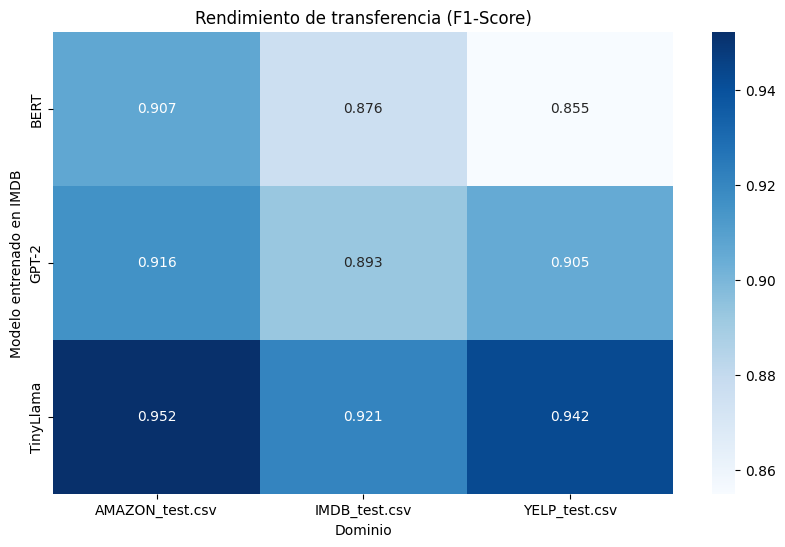


Análisis de degradación:
      Modelo Dominio Destino  Caída Absoluta   Caída %
0       BERT          AMAZON       -0.030713 -3.504720
1       BERT            YELP        0.021244  2.424199
2      GPT-2          AMAZON       -0.022732 -2.546144
3      GPT-2            YELP       -0.012656 -1.417516
4  TinyLlama          AMAZON       -0.031109 -3.377442
5  TinyLlama            YELP       -0.021425 -2.326075


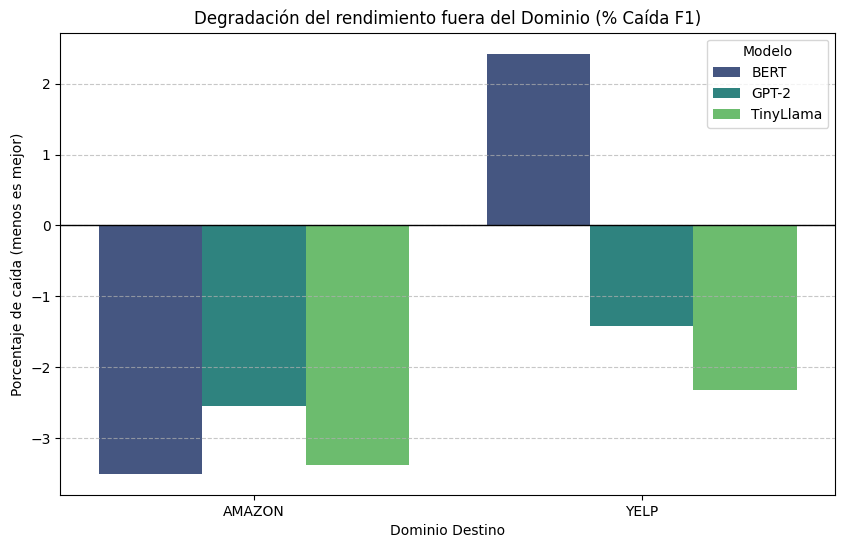

In [1]:
#
# EVALUACIÓN TRANSFERENCIA
#

# Instalación de librerías
!pip install -q transformers[torch] datasets accelerate torch scikit-learn sentencepiece peft bitsandbytes seaborn matplotlib

import os
import pandas as pd
import numpy as np
import torch
import seaborn as sns
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForSequenceClassification, GPT2Tokenizer, GPT2ForSequenceClassification
from peft import PeftModel, PeftConfig
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from google.colab import drive

# Semilla
import random
import sys
import transformers
import sklearn

def set_seed(seed=42):
    """
    Fija las semillas aleatorias para reproducibilidad.
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f"Semilla fijada en: {seed}")

# Fijación de semilla
set_seed(42)

# Versiones
print(f"Python version: {sys.version}")
print(f"Transformers version: {transformers.__version__}")
print(f"Torch version: {torch.__version__}")
print(f"Scikit-learn version: {sklearn.__version__}")
print("Entorno configurado para reproducibilidad.")

# Montar Drive y configuración
drive.mount('/content/drive')

BASE_PATH_DATA = "/content/drive/MyDrive/TFG_Data/PROCESSED"
BASE_PATH_MODELS = "/content/drive/MyDrive/TFG_Data/MODELS"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Usando dispositivo: {DEVICE}")

TARGET_DATASETS = [
    "IMDB_test.csv",
    "AMAZON_test.csv",
    "YELP_test.csv"
]

# Carga y evaluacion
def get_latest_checkpoint(model_path):

    if not os.path.exists(model_path):
        return None

    if os.path.exists(os.path.join(model_path, "model.safetensors")) or \
       os.path.exists(os.path.join(model_path, "adapter_model.safetensors")):
        return model_path

    subdirs = [d for d in os.listdir(model_path) if d.startswith("checkpoint-")]
    if not subdirs:
        return None

    subdirs.sort(key=lambda x: int(x.split('-')[1]))
    latest_checkpoint = subdirs[-1]
    full_path = os.path.join(model_path, latest_checkpoint)
    print(f"   -> Checkpoint detectado: {latest_checkpoint}")
    return full_path

def load_test_data(filename):
    path = os.path.join(BASE_PATH_DATA, filename)
    if not os.path.exists(path):
        print(f"Error: No se encuentra {path}")
        return [], []
    df = pd.read_csv(path)
    df = df.dropna(subset=['text', 'label'])
    print(f"   -> Cargadas {len(df)} muestras de {filename}")
    return df['text'].tolist(), df['label'].astype(int).tolist()

def evaluate_model(model, tokenizer, texts, labels, batch_size=32):
    model.eval()
    preds = []

    # Loop de inferencia por batches para no saturar RAM
    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i+batch_size]

        # Tokenización consistente con el entrenamiento
        inputs = tokenizer(
            batch_texts,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=128
        ).to(DEVICE)

        with torch.no_grad():
            outputs = model(**inputs)

        logits = outputs.logits
        batch_preds = torch.argmax(logits, dim=-1).cpu().numpy()
        preds.extend(batch_preds)

    return accuracy_score(labels, preds), f1_score(labels, preds, average='weighted')

results_data = []

# BERT
print("\nEvaluando BERT...")
path_bert_root = os.path.join(BASE_PATH_MODELS, "results_bert")
path_bert = get_latest_checkpoint(path_bert_root)
if os.path.exists(path_bert):
    # Cargamos tokenizer original y modelo finetuneado
    tokenizer = AutoTokenizer.from_pretrained("nlptown/bert-base-multilingual-uncased-sentiment")
    model = AutoModelForSequenceClassification.from_pretrained(path_bert).to(DEVICE)

    for ds in TARGET_DATASETS:
        print(f"Testing on {ds}...")
        texts, labels = load_test_data(ds)
        if texts:
            acc, f1 = evaluate_model(model, tokenizer, texts, labels)
            results_data.append({"Modelo": "BERT", "Dominio": ds, "Accuracy": acc, "F1-Score": f1})
    del model, tokenizer
    torch.cuda.empty_cache()
else:
    print(f"No se encontró el modelo en {path_bert}")

# GPT-2
print("\nEvaluando GPT-2...")
path_gpt_root = os.path.join(BASE_PATH_MODELS, "results_gpt2_final")
path_gpt = get_latest_checkpoint(path_gpt_root)
if os.path.exists(path_gpt):
    tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
    tokenizer.pad_token = tokenizer.eos_token
    tokenizer.padding_side = "right"

    model = GPT2ForSequenceClassification.from_pretrained(path_gpt).to(DEVICE)
    model.config.pad_token_id = tokenizer.eos_token_id

    for ds in TARGET_DATASETS:
        print(f"Testing on {ds}...")
        texts, labels = load_test_data(ds)
        if texts:
            acc, f1 = evaluate_model(model, tokenizer, texts, labels)
            results_data.append({"Modelo": "GPT-2", "Dominio": ds, "Accuracy": acc, "F1-Score": f1})
    del model, tokenizer
    torch.cuda.empty_cache()
else:
    print(f"No se encontró el modelo en {path_gpt}")

# LlaMA (LoRA)
print("\nEvaluando Llama (LoRA)...")
path_llama_root = os.path.join(BASE_PATH_MODELS, "results_llama")
path_llama = get_latest_checkpoint(path_llama_root)
if os.path.exists(path_llama):
    base_model = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"
    tokenizer = AutoTokenizer.from_pretrained(base_model)
    tokenizer.pad_token = tokenizer.eos_token
    tokenizer.padding_side = "right"

    model = AutoModelForSequenceClassification.from_pretrained(
        base_model, num_labels=2, torch_dtype=torch.bfloat16, device_map="auto"
    )
    model.config.pad_token_id = tokenizer.eos_token_id

    print("   Cargando adaptadores LoRA...")
    model = PeftModel.from_pretrained(model, path_llama)
    model = model.merge_and_unload()

    for ds in TARGET_DATASETS:
        print(f"Testing on {ds}...")
        texts, labels = load_test_data(ds)
        if texts:
            acc, f1 = evaluate_model(model, tokenizer, texts, labels)
            results_data.append({"Modelo": "TinyLlama", "Dominio": ds, "Accuracy": acc, "F1-Score": f1})
    del model, tokenizer
    torch.cuda.empty_cache()
else:
    print(f"No se encontró el modelo en {path_llama}")

# Resultados
if results_data:
    df_results = pd.DataFrame(results_data)
    print("\nTABLA DE RESULTADOS:")
    print(df_results)

    # Guardar
    df_results = pd.DataFrame(results_data)
    print("\nResultados generales:")
    print(df_results)
    df_results.to_csv("/content/drive/MyDrive/TFG_Data/resultados_finales_transferencia.csv", index=False)

    plt.figure(figsize=(10, 6))
    pivot = df_results.pivot(index="Modelo", columns="Dominio", values="F1-Score")
    sns.heatmap(pivot, annot=True, cmap="Blues", fmt=".3f")
    plt.title("Rendimiento de transferencia (F1-Score)")
    plt.ylabel("Modelo entrenado en IMDB")
    plt.show()

    print("\nAnálisis de degradación:")

    # Se normaliza respecto a IMDB para cada modelo
    df_drop = df_results.copy()
    models = df_drop['Modelo'].unique()

    drop_data = []
    for m in models:
        # Rendimiento base en IMDB
        base_f1 = df_drop[(df_drop['Modelo'] == m) & (df_drop['Dominio'] == 'IMDB_test.csv')]['F1-Score'].values[0]

        for ds in TARGET_DATASETS:
            if ds != 'IMDB_test.csv':
                curr_f1 = df_drop[(df_drop['Modelo'] == m) & (df_drop['Dominio'] == ds)]['F1-Score'].values[0]
                drop = base_f1 - curr_f1
                drop_pct = (drop / base_f1) * 100
                drop_data.append({'Modelo': m, 'Dominio Destino': ds.replace('_test.csv', ''), 'Caída Absoluta': drop, 'Caída %': drop_pct})

    df_drop_res = pd.DataFrame(drop_data)
    print(df_drop_res)

    plt.figure(figsize=(10, 6))
    sns.barplot(data=df_drop_res, x='Dominio Destino', y='Caída %', hue='Modelo', palette='viridis')
    plt.title("Degradación del rendimiento fuera del Dominio (% Caída F1)")
    plt.ylabel("Porcentaje de caída (menos es mejor)")
    plt.axhline(0, color='black', linewidth=1)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

else:
    print("No se generaron resultados. Revisa las rutas.")